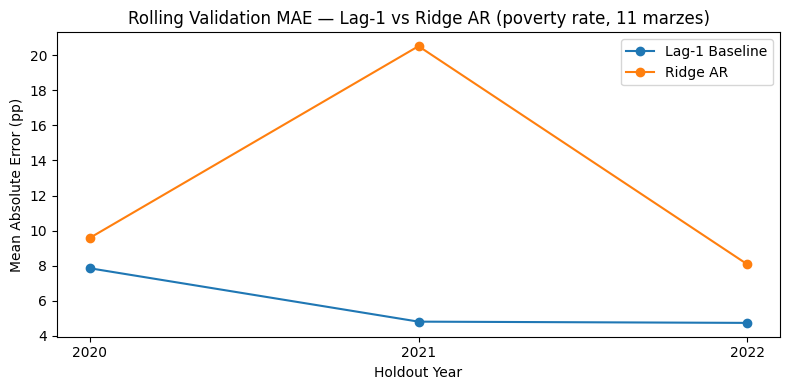

In [3]:
import pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv('../data/processed/results/forecast_rolling_validation.csv')
pr = df[df['target'] == 'poverty_rate']
mae = pr.groupby(['model', 'test_year'])['absolute_error'].mean().reset_index()
fig, ax = plt.subplots(figsize=(8, 4))
for model, grp in mae.groupby('model'):
    ax.plot(grp['test_year'], grp['absolute_error'], marker='o', label=model)
ax.set_xlabel('Holdout Year'); ax.set_ylabel('Mean Absolute Error (pp)')
ax.set_title('Rolling Validation MAE — Lag-1 vs Ridge AR (poverty rate, 11 marzes)')
ax.set_xticks([2020, 2021, 2022]); ax.legend(); plt.tight_layout()
plt.savefig('../final_paper/figures/rolling-validation-mae.png', dpi=150, bbox_inches='tight')
plt.show()